# PHASE 4 - Linear Regression

This notebook trains a Linear Regression model using the chronological splits created in PHASE 3. It reports MAE, RMSE, R2, and training time for validation and test data.

Leakage prevention: `casual`, `registered`, and `cnt` are excluded from predictors. The scaler is fit only on the training set through a scikit-learn Pipeline.

In [1]:
from pathlib import Path
from time import perf_counter
import pickle

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
base_dir = Path(".") if (Path(".") / "data/processed/train.csv").exists() else Path("..")
processed_dir = base_dir / "data/processed"
results_dir = base_dir / "results"
metrics_dir = results_dir / "metrics"
figures_dir = results_dir / "figures"
models_dir = base_dir / "models"
for directory in [metrics_dir, figures_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
def load_split(name):
    path = processed_dir / f"{name}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run PHASE 3 first.")
    return pd.read_csv(path, parse_dates=["timestamp", "dteday"])

train_df = load_split("train")
validation_df = load_split("validation")
test_df = load_split("test")

target_column = "cnt"
excluded_columns = {
    target_column, "instant", "dteday", "timestamp",
    "casual", "registered",
}
feature_columns = [column for column in train_df.columns if column not in excluded_columns]

X_train, y_train = train_df[feature_columns], train_df[target_column]
X_validation, y_validation = validation_df[feature_columns], validation_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

print(f"Features: {len(feature_columns)}")
print(feature_columns)
print(f"Train/validation/test: {len(train_df)}/{len(validation_df)}/{len(test_df)}")

NameError: name 'processed_dir' is not defined

: 

## Fit on train only

In [3]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])

start_time = perf_counter()
model.fit(X_train, y_train)
training_time = perf_counter() - start_time

validation_predictions = model.predict(X_validation)
test_predictions = model.predict(X_test)
print(f"Training time: {training_time:.4f} seconds")

Training time: 0.0693 seconds


In [4]:
def regression_metrics(y_true, predictions, split_name):
    return {
        "model": "Linear Regression",
        "split": split_name,
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "R2": r2_score(y_true, predictions),
        "Training Time": training_time,
    }

metrics = pd.DataFrame([
    regression_metrics(y_validation, validation_predictions, "validation"),
    regression_metrics(y_test, test_predictions, "test"),
])
display(metrics.round(4))
metrics.to_csv(metrics_dir / "linear_regression_metrics.csv", index=False)
print(f"Saved metrics to: {metrics_dir / 'linear_regression_metrics.csv'}")

,model,split,MAE,RMSE,R2,Training Time
0,Linear Regression,validation,57.6307,81.3603,0.8684,0.0693
1,Linear Regression,test,57.7926,83.9422,0.8461,0.0693


Saved metrics to: results\metrics\linear_regression_metrics.csv


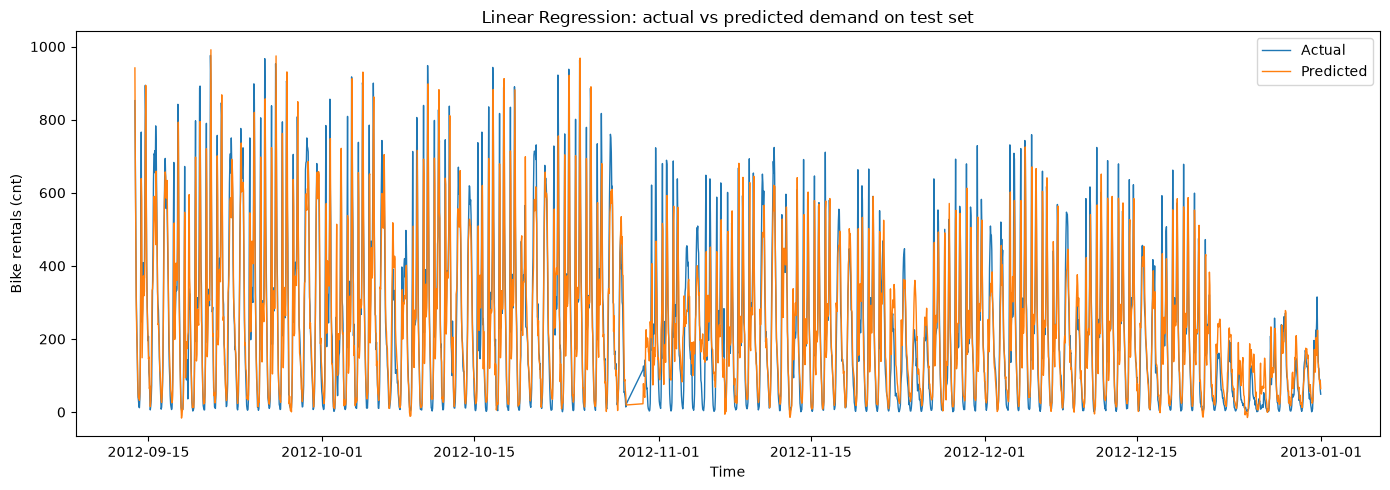

In [5]:
comparison = pd.DataFrame({
    "timestamp": test_df["timestamp"],
    "actual": y_test.to_numpy(),
    "predicted": test_predictions,
})

plt.figure(figsize=(14, 5))
plt.plot(comparison["timestamp"], comparison["actual"], label="Actual", linewidth=1)
plt.plot(comparison["timestamp"], comparison["predicted"], label="Predicted", linewidth=1)
plt.title("Linear Regression: actual vs predicted demand on test set")
plt.xlabel("Time")
plt.ylabel("Bike rentals (cnt)")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "linear_regression_actual_vs_predicted.png", dpi=150)
plt.show()

In [6]:
model_path = models_dir / "linear_regression.pkl"
with model_path.open("wb") as model_file:
    pickle.dump({"model": model, "feature_columns": feature_columns}, model_file)
print(f"Saved model to: {model_path}")

Saved model to: models\linear_regression.pkl


## Phase 4 conclusion

The Linear Regression baseline and its test predictions are saved. Later model notebooks can compare their metrics with `results/metrics/linear_regression_metrics.csv`.